In [3]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

In [4]:
df = pd.read_csv(r"C:\Users\bhanu\Downloads\StructCompose\data\metadata\master_metadata.csv")

IMAGE_DIR = r"C:\Users\bhanu\Downloads\StructCompose\data\raw\CADB\images"

print(df.shape)
df.head()

(9497, 13)


,image_name,Light,Symmetry,Object,score,RuleOfThirds,Repetition,BalacingElements,ColorHarmony,MotionBlur,VividColor,DoF,Content
0,10003.jpg,0.4,0.0,-0.4,0.650,0.4,0.0,0.0,0.8,0.0,0.4,0.0,0.6
1,10007.jpg,0.2,0.0,0.4,0.500,0.0,0.0,0.0,0.2,-0.2,-0.2,-0.2,0.2
2,10008.jpg,0.0,0.2,0.2,0.400,-0.4,0.0,0.0,0.2,0.0,-0.4,0.2,0.4
3,1001.jpg,-0.2,0.0,0.8,0.438,-0.2,0.0,0.2,0.0,0.0,0.0,0.0,0.4
4,10010.jpg,0.2,0.0,-0.4,0.550,-0.4,0.2,0.0,0.4,0.0,0.4,0.2,1.0


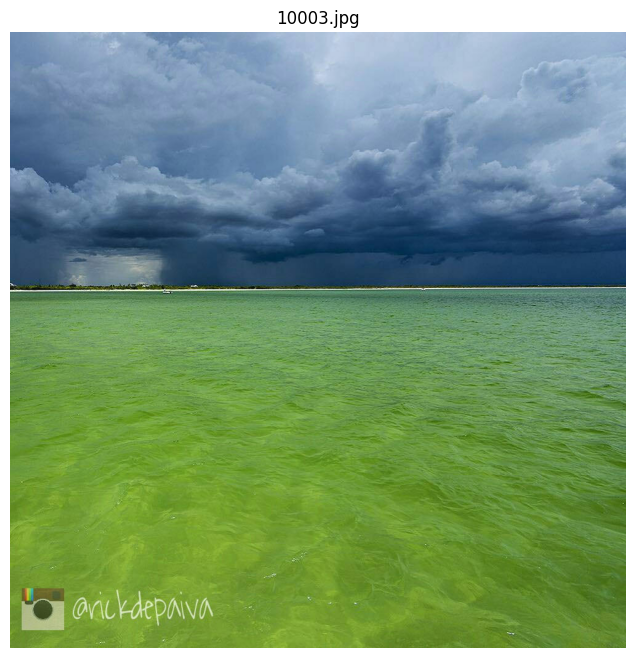

In [5]:
sample_image = df.iloc[0]["image_name"]

image_path = os.path.join(IMAGE_DIR, sample_image)

img = cv2.imread(image_path)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,8))
plt.imshow(img_rgb)
plt.title(sample_image)
plt.axis("off")
plt.show()

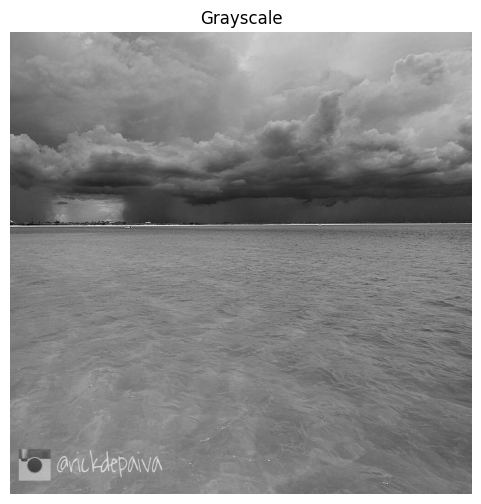

In [6]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(6,6))
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")
plt.show()

In [7]:
mean_brightness = np.mean(gray)

std_brightness = np.std(gray)

print("Mean Brightness:", mean_brightness)
print("Brightness Variation:", std_brightness)

Mean Brightness: 126.44752550147156
Brightness Variation: 31.34364201801225


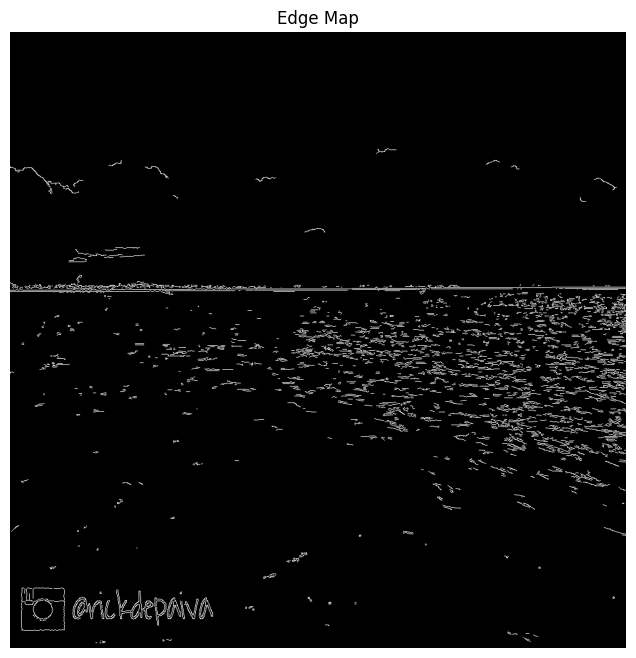

In [8]:
edges = cv2.Canny(gray, 100, 200)

plt.figure(figsize=(8,8))
plt.imshow(edges, cmap="gray")
plt.title("Edge Map")
plt.axis("off")
plt.show()

In [9]:
edge_density = np.sum(edges > 0) / edges.size

print("Edge Density:", edge_density)

Edge Density: 0.023578818783613988


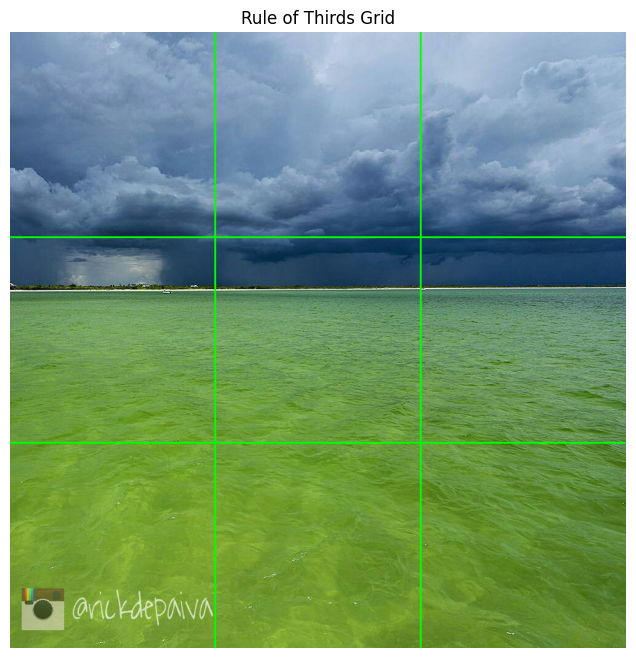

In [10]:
img_copy = img_rgb.copy()

h, w, _ = img_copy.shape

# Vertical lines
x1 = w // 3
x2 = 2 * w // 3

# Horizontal lines
y1 = h // 3
y2 = 2 * h // 3

cv2.line(img_copy, (x1,0), (x1,h), (0,255,0), 2)
cv2.line(img_copy, (x2,0), (x2,h), (0,255,0), 2)

cv2.line(img_copy, (0,y1), (w,y1), (0,255,0), 2)
cv2.line(img_copy, (0,y2), (w,y2), (0,255,0), 2)

plt.figure(figsize=(8,8))
plt.imshow(img_copy)
plt.title("Rule of Thirds Grid")
plt.axis("off")
plt.show()

In [11]:
left_half = gray[:, :w//2]
right_half = gray[:, w//2:]

left_weight = np.mean(left_half)
right_weight = np.mean(right_half)

print("Left Weight:", left_weight)
print("Right Weight:", right_weight)

Left Weight: 128.0423056943057
Right Weight: 124.8559285026351


In [12]:
balance_score = 1 - abs(left_weight - right_weight) / 255

print("Balance Score:", balance_score)

Balance Score: 0.9875044031699192


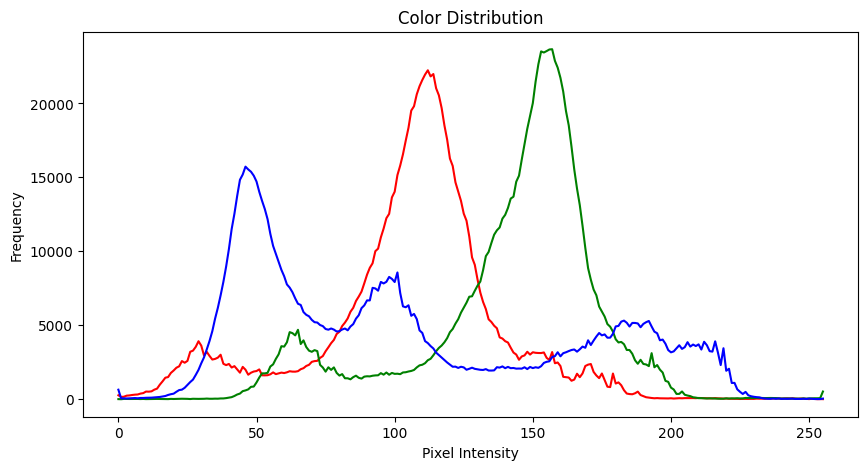

In [13]:
colors = ("r", "g", "b")

plt.figure(figsize=(10,5))

for i, color in enumerate(colors):

    hist = cv2.calcHist([img_rgb], [i], None, [256], [0,256])

    plt.plot(hist, color=color)

plt.title("Color Distribution")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.show()

In [2]:
!pip uninstall opencv-python -y

Found existing installation: opencv-python 4.12.0.88
Uninstalling opencv-python-4.12.0.88:
  Successfully uninstalled opencv-python-4.12.0.88


You can safely remove it manually.


In [3]:
!pip install opencv-contrib-python

  Using cached opencv_contrib_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached opencv_contrib_python-4.13.0.92-cp37-abi3-win_amd64.whl (46.5 MB)



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import cv2

print(cv2.__version__)

print(hasattr(cv2, "saliency"))

4.13.0
True


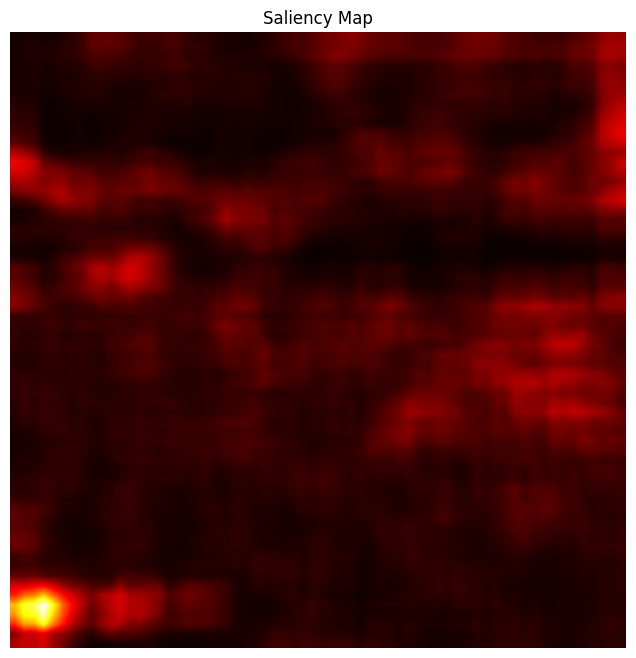

In [14]:
saliency = cv2.saliency.StaticSaliencySpectralResidual_create()

success, saliency_map = saliency.computeSaliency(img)

saliency_map = (saliency_map * 255).astype("uint8")

plt.figure(figsize=(8,8))
plt.imshow(saliency_map, cmap="hot")
plt.title("Saliency Map")
plt.axis("off")
plt.show()

In [15]:
threshold = 100

important_regions = saliency_map > threshold

negative_space_ratio = 1 - np.mean(important_regions)

print("Negative Space Ratio:", negative_space_ratio)

Negative Space Ratio: 0.9941686684943428


In [16]:
composition_features = {

    "brightness_mean": mean_brightness,
    "brightness_std": std_brightness,
    "edge_density": edge_density,
    "balance_score": balance_score,
    "negative_space_ratio": negative_space_ratio

}

print(composition_features)

{'brightness_mean': np.float64(126.44752550147156), 'brightness_std': np.float64(31.34364201801225), 'edge_density': np.float64(0.023578818783613988), 'balance_score': np.float64(0.9875044031699192), 'negative_space_ratio': np.float64(0.9941686684943428)}


In [17]:
feature_df = pd.DataFrame([composition_features])

feature_df.to_csv(
    r"C:\Users\bhanu\Downloads\StructCompose\data\metadata\sample_composition_features.csv",
    index=False
)

print("Saved composition features")

Saved composition features
